In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
path = kagglehub.dataset_download("sinadehestani/wine-quality-red-and-white")
print(path)

import os
print(os.listdir(path))

100%|██████████| 100k/100k [00:00<00:00, 277kB/s]

Extracting files...
/root/.cache/kagglehub/datasets/sinadehestani/wine-quality-red-and-white/versions/1
['wine_quality_merged.csv']


In [4]:
df = pd.read_csv(f"{path}/wine_quality_merged.csv")
print(df.shape)
df.head()

(6497, 13)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [6]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [7]:
print(df.columns.tolist())
df['type'].value_counts()

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'type']


,count
type,
white,4898
red,1599


In [8]:
df['quality'].value_counts().sort_index()

,count
quality,
3,30
4,216
5,2138
6,2836
7,1079
8,193
9,5


In [9]:
df['quality_label'] = (df['quality'] >= 7).astype(int)
df['quality_label'].value_counts()

,count
quality_label,
0,5220
1,1277


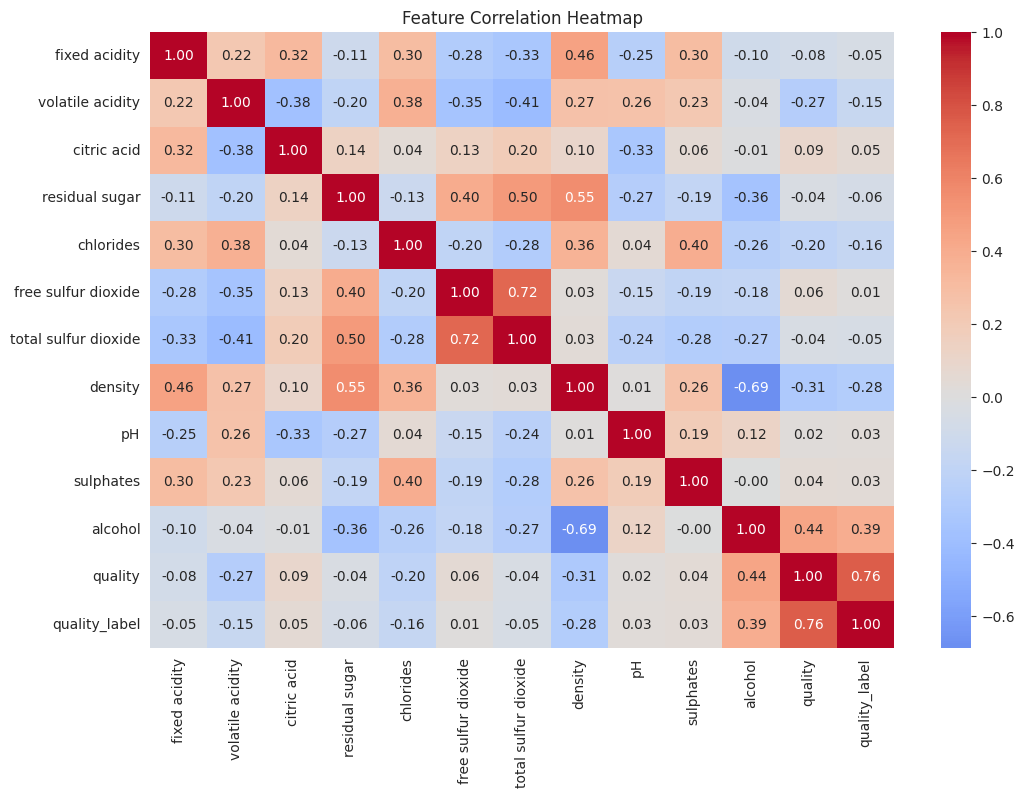

In [12]:
plt.figure(figsize=(12,8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

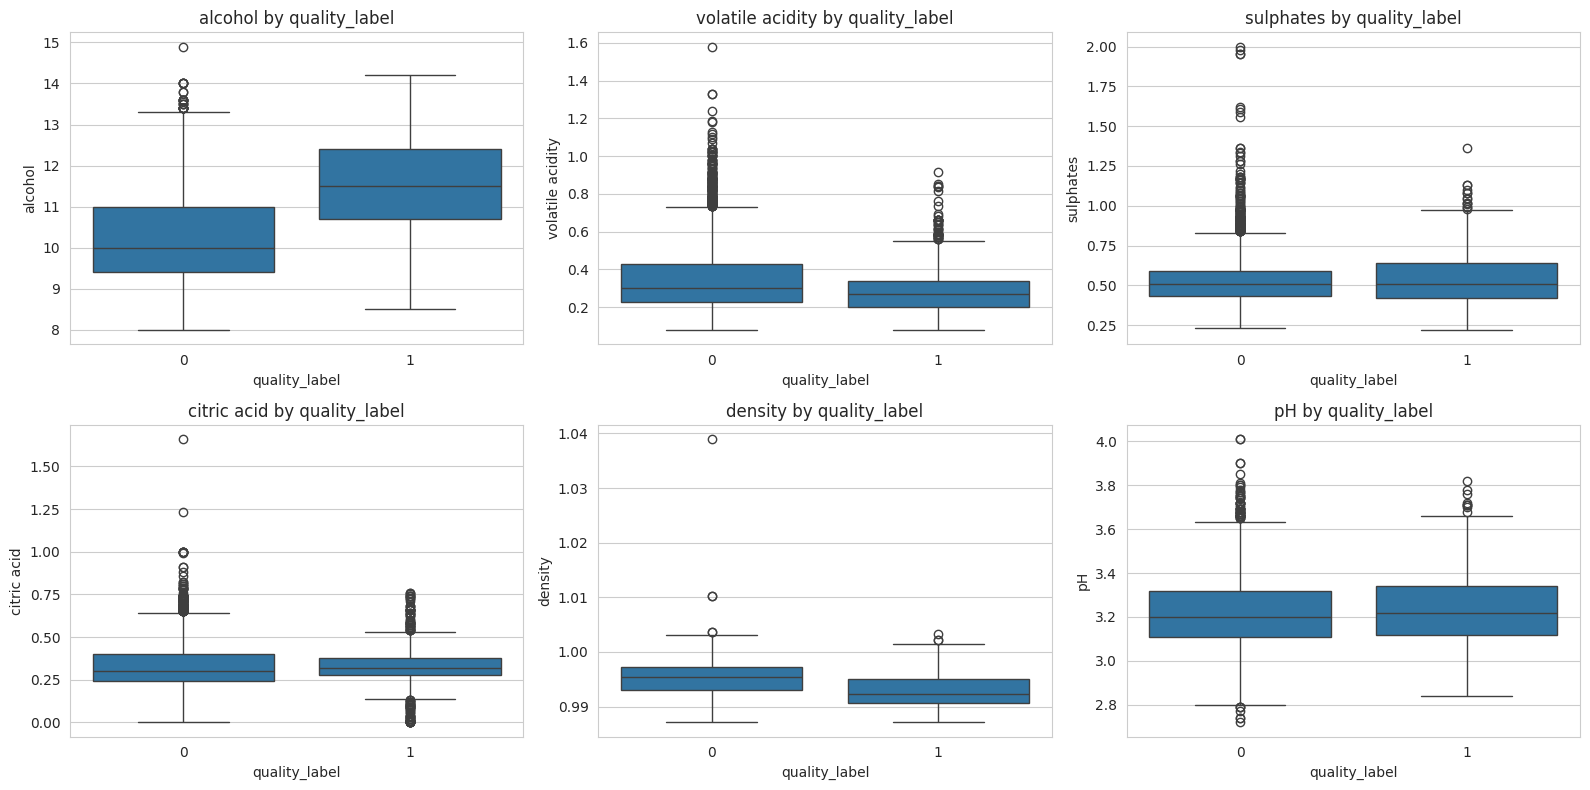

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
features_to_plot = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'density', 'pH']

for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.boxplot(x='quality_label', y=feat, data=df, ax=ax)
    ax.set_title(f'{feat} by quality_label')

plt.tight_layout()
plt.show()

In [15]:

pd.crosstab(df['type'], df['quality_label'], normalize='index')

quality_label,0,1
type,,
red,0.864290,0.135710
white,0.783585,0.216415


In [16]:

df['type_encoded'] = df['type'].map({'red': 0, 'white': 1})
df[['type', 'type_encoded']].head()

,type,type_encoded
0,red,0
1,red,0
2,red,0
3,red,0
4,red,0


In [18]:
feature_cols = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
                 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
                 'pH', 'sulphates', 'alcohol', 'type_encoded']

X = df[feature_cols]
y = df['quality_label']

print(X.shape, y.shape)

(6497, 12) (6497,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train: (5197, 12) Test: (1300, 12)
quality_label
0    0.803541
1    0.196459
Name: proportion, dtype: float64
quality_label
0    0.803077
1    0.196923
Name: proportion, dtype: float64


In [20]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

print("No scaling sample:\n", X_train.iloc[0].values[:3])
print("StandardScaler sample:\n", X_train_std[0][:3])
print("MinMaxScaler sample:\n", X_train_mm[0][:3])

No scaling sample:
 [6.6  0.32 0.33]
StandardScaler sample:
 [-0.47645146 -0.1255194   0.0657825 ]
MinMaxScaler sample:
 [0.20512821 0.16       0.26829268]


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import time

scaling_versions = {
    'No Scaling': (X_train, X_test),
    'StandardScaler': (X_train_std, X_test_std),
    'MinMaxScaler': (X_train_mm, X_test_mm)
}

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
distance_metrics = ['euclidean', 'manhattan', 'minkowski']
weight_options = ['uniform', 'distance']

results = []

for scale_name, (Xtr, Xte) in scaling_versions.items():
    for k in k_values:
        for metric in distance_metrics:
            for weight in weight_options:
                knn = KNeighborsClassifier(
                    n_neighbors=k,
                    metric=metric,
                    weights=weight,
                    p=3 if metric == 'minkowski' else 2  # p=3 to distinguish minkowski from euclidean
                )
                knn.fit(Xtr, y_train)
                y_pred = knn.predict(Xte)

                acc = accuracy_score(y_test, y_pred)
                f1 = f1_score(y_test, y_pred)

                results.append({
                    'scaling': scale_name,
                    'k': k,
                    'metric': metric,
                    'weight': weight,
                    'accuracy': acc,
                    'f1_score': f1
                })

results_df = pd.DataFrame(results)
print(results_df.shape)
results_df.head(10)

(162, 6)


,scaling,k,metric,weight,accuracy,f1_score
0,No Scaling,1,euclidean,uniform,0.834615,0.587332
1,No Scaling,1,euclidean,distance,0.834615,0.587332
2,No Scaling,1,manhattan,uniform,0.836154,0.589595
3,No Scaling,1,manhattan,distance,0.836154,0.589595
4,No Scaling,1,minkowski,uniform,0.842308,0.598826
5,No Scaling,1,minkowski,distance,0.842308,0.598826
6,No Scaling,3,euclidean,uniform,0.796923,0.431034
7,No Scaling,3,euclidean,distance,0.834615,0.553015
8,No Scaling,3,manhattan,uniform,0.806923,0.464819
9,No Scaling,3,manhattan,distance,0.842308,0.577320


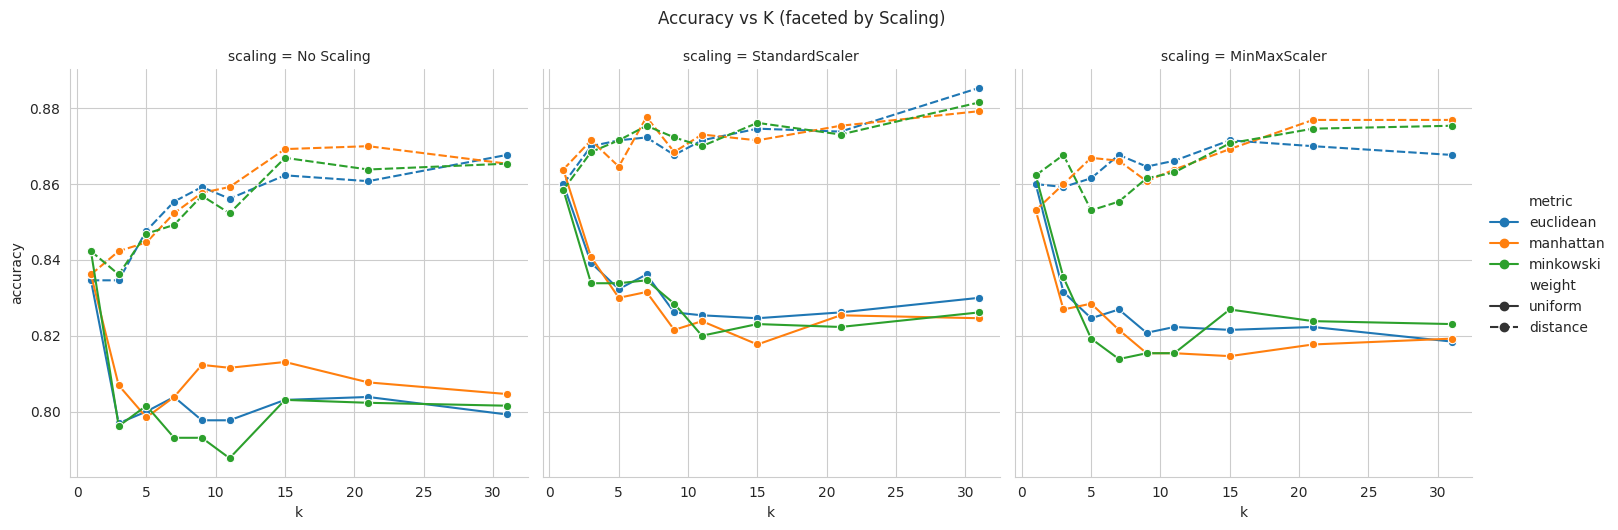

In [23]:
g = sns.relplot(
    data=results_df,
    x='k', y='accuracy',
    hue='metric', style='weight',
    col='scaling',
    kind='line', marker='o',
    height=5, aspect=1
)
g.fig.suptitle('Accuracy vs K (faceted by Scaling)', y=1.05)
plt.show()

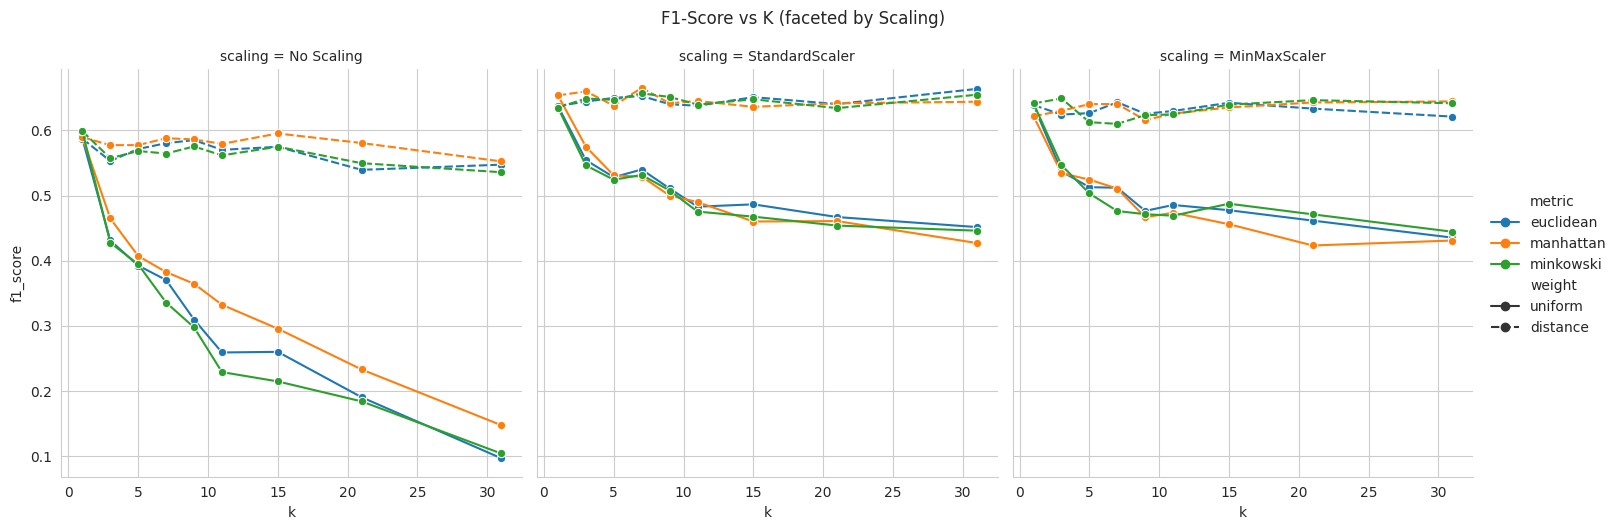

In [24]:
g = sns.relplot(
    data=results_df,
    x='k', y='f1_score',
    hue='metric', style='weight',
    col='scaling',
    kind='line', marker='o',
    height=5, aspect=1
)
g.fig.suptitle('F1-Score vs K (faceted by Scaling)', y=1.05)
plt.show()

In [25]:
best_f1 = results_df.sort_values('f1_score', ascending=False).head(10)
best_f1

,scaling,k,metric,weight,accuracy,f1_score
75,StandardScaler,7,manhattan,distance,0.877692,0.665263
103,StandardScaler,31,euclidean,distance,0.885385,0.663657
63,StandardScaler,3,manhattan,distance,0.871538,0.659878
77,StandardScaler,7,minkowski,distance,0.875385,0.656780
107,StandardScaler,31,minkowski,distance,0.881538,0.654709
56,StandardScaler,1,manhattan,uniform,0.863846,0.653620
57,StandardScaler,1,manhattan,distance,0.863846,0.653620
73,StandardScaler,7,euclidean,distance,0.872308,0.652720
83,StandardScaler,9,minkowski,distance,0.872308,0.651261
91,StandardScaler,15,euclidean,distance,0.874615,0.650964


In [26]:
best_acc = results_df.sort_values('accuracy', ascending=False).head(10)
best_acc

,scaling,k,metric,weight,accuracy,f1_score
103,StandardScaler,31,euclidean,distance,0.885385,0.663657
107,StandardScaler,31,minkowski,distance,0.881538,0.654709
105,StandardScaler,31,manhattan,distance,0.879231,0.643991
75,StandardScaler,7,manhattan,distance,0.877692,0.665263
153,MinMaxScaler,21,manhattan,distance,0.876923,0.642857
159,MinMaxScaler,31,manhattan,distance,0.876923,0.644444
95,StandardScaler,15,minkowski,distance,0.876154,0.647702
77,StandardScaler,7,minkowski,distance,0.875385,0.656780
99,StandardScaler,21,manhattan,distance,0.875385,0.641593
161,MinMaxScaler,31,minkowski,distance,0.875385,0.641593


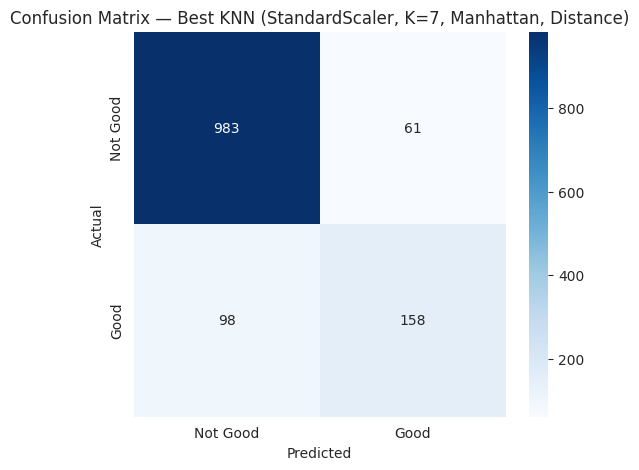

              precision    recall  f1-score   support

    Not Good       0.91      0.94      0.93      1044
        Good       0.72      0.62      0.67       256

    accuracy                           0.88      1300
   macro avg       0.82      0.78      0.80      1300
weighted avg       0.87      0.88      0.87      1300



In [27]:
final_knn = KNeighborsClassifier(n_neighbors=7, metric='manhattan', weights='distance')
final_knn.fit(X_train_std, y_train)
y_pred_final = final_knn.predict(X_test_std)

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Good', 'Good'], yticklabels=['Not Good', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Best KNN (StandardScaler, K=7, Manhattan, Distance)')
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['Not Good', 'Good']))